# NEBULA pilot PMF analysis

A reproducible first-pass analysis of NEBULA search and feedback events. The default input is a clearly labelled sample fixture; replace it with an export from `/v1/research/export?format=csv` before making research claims.

## tl;dr

This notebook measures search volume, zero-result rate, latency, ranking-mode usage, session coverage, and usefulness feedback. It is an analysis template until a real pilot export is supplied.

## Context & Methods

The unit of analysis is an event persisted by NEBULA. Search events measure retrieval behavior; feedback events measure a user's judgement of a result. Session IDs are anonymous browser-local identifiers.

### Key Assumptions

- A zero-result search is a retrieval failure signal, not proof that the corpus lacks the answer.
- Useful feedback is descriptive pilot evidence, not a product-market-fit estimate by itself.
- Latency is recorded by the API in nanoseconds and reported here in milliseconds.
- The sample fixture is synthetic and must not be included in university findings.

## Data

### 1. Load and validate the export

In [1]:
from collections import Counter
import csv
from pathlib import Path
from statistics import mean

repo_root = Path.cwd()
if not (repo_root / 'data').exists():
    repo_root = repo_root.parent
real_export = repo_root / 'data/nebula-research.csv'
sample_export = repo_root / 'data/nebula-research.sample.csv'
INPUT_PATH = real_export if real_export.exists() else sample_export

required_columns = {'type', 'sessionId', 'timestamp', 'query', 'mode', 'results', 'latencyNanos', 'documentId', 'sourcePath', 'useful'}
with INPUT_PATH.open(newline='', encoding='utf-8') as handle:
    reader = csv.DictReader(handle)
    missing = required_columns - set(reader.fieldnames or [])
    if missing:
        raise ValueError(f'Missing columns: {sorted(missing)}')
    events = [{key: (value or '').strip() for key, value in row.items()} for row in reader]

for event in events:
    if event['type'] == 'search':
        event['results'] = int(event['results'])
        event['latencyMs'] = int(event['latencyNanos']) / 1_000_000
    elif event['type'] == 'feedback':
        event['usefulBool'] = event['useful'].lower() == 'true'

search_events = [event for event in events if event['type'] == 'search']
feedback_events = [event for event in events if event['type'] == 'feedback']
print(f'Input: {INPUT_PATH}')
print(f'Events: {len(events)} | searches: {len(search_events)} | feedback: {len(feedback_events)}')

Input: C:\Users\USER\OneDrive\Desktop\NEBULA\data\nebula-research.sample.csv
Events: 7 | searches: 4 | feedback: 3


## Results

### 2. Compute PMF-oriented measures

In [2]:
search_count = len(search_events)
zero_result_rate = sum(event['results'] == 0 for event in search_events) / search_count if search_count else 0
average_latency_ms = mean(event['latencyMs'] for event in search_events) if search_events else 0
useful_rate = sum(event['usefulBool'] for event in feedback_events) / len(feedback_events) if feedback_events else 0
summary = {
    'searches': search_count,
    'zero_result_rate': round(zero_result_rate, 3),
    'average_latency_ms': round(average_latency_ms, 2),
    'feedback_events': len(feedback_events),
    'useful_rate': round(useful_rate, 3),
    'sessions': len({event['sessionId'] for event in events if event['sessionId']}),
}
mode_counts = Counter(event['mode'] for event in search_events)
summary, dict(mode_counts)

({'searches': 4,
  'zero_result_rate': 0.25,
  'average_latency_ms': 19.25,
  'feedback_events': 3,
  'useful_rate': 0.667,
  'sessions': 2},
 {'bm25': 2, 'hybrid': 1, 'semantic': 1})

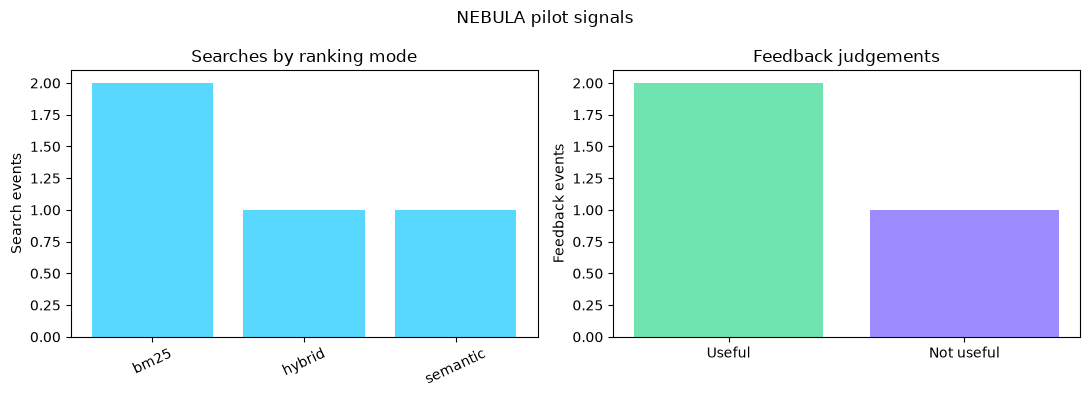

In [3]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].bar(list(mode_counts.keys()) or ['none'], list(mode_counts.values()) or [0], color='#59d8ff')
axes[0].set_title('Searches by ranking mode')
axes[0].set_ylabel('Search events')
axes[0].tick_params(axis='x', rotation=25)
axes[1].bar(['Useful', 'Not useful'], [sum(event['usefulBool'] for event in feedback_events), sum(not event['usefulBool'] for event in feedback_events)], color=['#70e4b0', '#9c8cff'])
axes[1].set_title('Feedback judgements')
axes[1].set_ylabel('Feedback events')
fig.suptitle('NEBULA pilot signals')
fig.tight_layout()
plt.show()

## Takeaways

Use the executed `summary` output and charts to write study-specific conclusions after replacing the sample fixture with a real export. Report the corpus version, pilot dates, number of sessions, and task protocol alongside these metrics.

A responsible interpretation should distinguish retrieval quality (zero-result rate and usefulness) from product experience (latency, reformulation behavior, and repeat intent). Small samples should be presented as exploratory evidence with uncertainty, not as proof of product-market fit.